In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
import xgboost as xgb
from scipy.sparse import csr_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/RU_youtube_trending_data.csv")

merge_map = {
    31: 1,
    30: 18,
    34: 23,
    27: 26,
    41: 39
}

df["categoryId"] = df["categoryId"].replace(merge_map)

drop_categories = [32, 33, 35, 36, 37, 38, 39, 40, 42, 43, 44]
df = df[~df["categoryId"].isin(drop_categories)]

df = df.dropna(subset=["title", "description", "tags", "categoryId"])

df["text"] = df["title"].astype(str) + " " + df["description"].astype(str) + " " + df["tags"].astype(str)

In [4]:
X = df["text"].tolist()
y = df["categoryId"].astype(int).tolist()

In [5]:
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(X)
X_tfidf = X_tfidf.astype("float32")

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [8]:
X_train_sparse = csr_matrix(X_train)
X_test_sparse = csr_matrix(X_test)

In [9]:
dtrain = xgb.DMatrix(X_train_sparse, label=y_train)
dtest = xgb.DMatrix(X_test_sparse, label=y_test)

In [10]:
params = {
    "objective": "multi:softmax",
    "num_class": len(le.classes_),
    "eval_metric": "mlogloss",
    "learning_rate": 0.1,
    "max_depth": 3,
    "subsample": 0.6,
    "colsample_bytree": 0.6,
    "tree_method": "hist",
    "max_bin": 64
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    evals=[(dtest, "eval")],
    verbose_eval=True
)

[0]	eval-mlogloss:2.43450
[1]	eval-mlogloss:2.29375
[2]	eval-mlogloss:2.18118
[3]	eval-mlogloss:2.08718
[4]	eval-mlogloss:2.00712
[5]	eval-mlogloss:1.93755
[6]	eval-mlogloss:1.87736
[7]	eval-mlogloss:1.82232
[8]	eval-mlogloss:1.77335
[9]	eval-mlogloss:1.72764
[10]	eval-mlogloss:1.68646
[11]	eval-mlogloss:1.64773
[12]	eval-mlogloss:1.61316
[13]	eval-mlogloss:1.58118
[14]	eval-mlogloss:1.55042
[15]	eval-mlogloss:1.52254
[16]	eval-mlogloss:1.49716
[17]	eval-mlogloss:1.47330
[18]	eval-mlogloss:1.45005
[19]	eval-mlogloss:1.42775
[20]	eval-mlogloss:1.40721
[21]	eval-mlogloss:1.38773
[22]	eval-mlogloss:1.36966
[23]	eval-mlogloss:1.35226
[24]	eval-mlogloss:1.33513
[25]	eval-mlogloss:1.31945
[26]	eval-mlogloss:1.30405
[27]	eval-mlogloss:1.29004
[28]	eval-mlogloss:1.27601
[29]	eval-mlogloss:1.26339
[30]	eval-mlogloss:1.25075
[31]	eval-mlogloss:1.23814
[32]	eval-mlogloss:1.22623
[33]	eval-mlogloss:1.21479
[34]	eval-mlogloss:1.20386
[35]	eval-mlogloss:1.19310
[36]	eval-mlogloss:1.18287
[37]	eval-m

In [11]:
y_pred = model.predict(dtest)

acc = accuracy_score(y_test, y_pred)
print("Точность: ", acc)

print(classification_report(y_test, y_pred))

Точность:  0.7814219976540648
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      2876
           1       0.87      0.87      0.87      2493
           2       0.83      0.80      0.81      2699
           3       0.92      0.72      0.81       318
           4       0.93      0.85      0.89      3116
           5       0.93      0.71      0.80       328
           6       0.92      0.89      0.90      6549
           7       0.57      0.76      0.66      7512
           8       0.84      0.70      0.76      2630
           9       0.70      0.65      0.67      6902
          10       0.84      0.89      0.87      5684
          11       0.90      0.57      0.70      1454
          12       0.92      0.61      0.73      1064
          13       0.98      0.77      0.86       707

    accuracy                           0.78     44332
   macro avg       0.86      0.75      0.79     44332
weighted avg       0.80      0.78      0.78     44

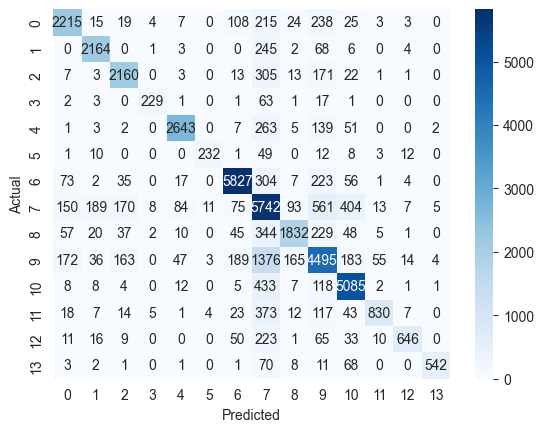

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
CATEGORIES = {
    1: "Фильмы и анимация",
    2: "Автомобили",
    10: "Музыка",
    15: "Животные",
    17: "Спорт",
    18: "Короткометражки",
    19: "Путешествия и события",
    20: "Игры",
    21: "Видеоблоги",
    22: "Люди",
    23: "Юмор",
    24: "Развлечения",
    25: "Новости и политика",
    26: "Как сделать",
    28: "Наука и технологии",
    29: None
}


def category_id_to_name(category_id):
    if not category_id:
        return None

    return CATEGORIES[int(category_id)]

y_pred_labels = le.inverse_transform(y_pred.astype(int))

for idx, (true, pred) in enumerate(zip(y_test[:100], y_pred_labels[:100])):
    print(f"Index {idx} -> True class: {category_id_to_name(le.inverse_transform([true])[0])}, Predicted: {category_id_to_name(pred)}")

Index 0 -> True class: Люди, Predicted: Люди
Index 1 -> True class: Фильмы и анимация, Predicted: Фильмы и анимация
Index 2 -> True class: Игры, Predicted: Игры
Index 3 -> True class: Игры, Predicted: Игры
Index 4 -> True class: Юмор, Predicted: Юмор
Index 5 -> True class: Игры, Predicted: Игры
Index 6 -> True class: Новости и политика, Predicted: Новости и политика
Index 7 -> True class: Как сделать, Predicted: Как сделать
Index 8 -> True class: Музыка, Predicted: Музыка
Index 9 -> True class: None, Predicted: Люди
Index 10 -> True class: Развлечения, Predicted: Развлечения
Index 11 -> True class: Юмор, Predicted: Развлечения
Index 12 -> True class: Развлечения, Predicted: Развлечения
Index 13 -> True class: Люди, Predicted: Люди
Index 14 -> True class: Фильмы и анимация, Predicted: Фильмы и анимация
Index 15 -> True class: Новости и политика, Predicted: Новости и политика
Index 16 -> True class: Развлечения, Predicted: Развлечения
Index 17 -> True class: Развлечения, Predicted: Развл

In [14]:
joblib.dump(model, "model/xgb_classifier.pkl")
joblib.dump(vectorizer, "model/tfidf_vectorizer.pkl")
joblib.dump(le, "model/label_encoder.pkl")

['model/label_encoder.pkl']